# withGyro Experiment 0.2 — nonlinear temporal decoder probe

Analysis-only notebook for the finalized `structured_residual_gru_v1` artifacts. The training pipeline compares `accel30`, `angular30`, and `combined60` under `fixed250` and `relative10` with Linear, Linear+Local, Linear+Transition, Linear+Local+Transition, and GRU decoders. No SNN is used.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve().parent.parent if Path.cwd().name == 'withGyro' else Path.cwd().resolve()
while not (repo_root / 'AGENTS.md').is_file():
    if repo_root.parent == repo_root:
        raise FileNotFoundError('Could not locate repository root')
    repo_root = repo_root.parent
artifact_root = (
    repo_root / 'notebooks' / 'artifacts' / 'withGyro' /
    'experiment_0_2_nonlinear_temporal_decoder_probe' / 'structured_residual_gru_v1'
)
required = {
    'results': artifact_root / 'experiment_0_2_results.csv',
    'summary': artifact_root / 'experiment_0_2_summary.csv',
    'paired': artifact_root / 'experiment_0_2_paired_decoder_deltas.csv',
    'sensor': artifact_root / 'experiment_0_2_sensor_deltas.csv',
    'synergy': artifact_root / 'experiment_0_2_nonlinear_synergy.csv',
    'conclusion': artifact_root / 'experiment_0_2_conclusion.json',
}
missing = [str(path) for path in required.values() if not path.is_file()]
if missing:
    raise FileNotFoundError('Run/finalize Experiment 0.2 first. Missing:\n' + '\n'.join(missing))
results = pd.read_csv(required['results'])
summary = pd.read_csv(required['summary'])
paired = pd.read_csv(required['paired'])
sensor = pd.read_csv(required['sensor'])
synergy = pd.read_csv(required['synergy'])
conclusion = json.loads(required['conclusion'].read_text(encoding='utf-8'))
conclusion

{'experiment_id': 'withGyro_experiment_0_2_nonlinear_temporal_decoder_probe',
 'fixed250_combined_local_transition_mean_delta_vs_linear': 0.022473544973544958,
 'fixed250_combined_local_transition_minus_gru_mean': 0.03865740740740738,
 'linear_baseline_reproduction_max_abs_difference': 5.551115123125783e-17,
 'primary_question': 'Where does additional information from angular events and accel+angular fusion become accessible: linearly, through structured local/transition nonlinearities, or through a generic GRU?',
 'protocol_version': 'structured_residual_gru_v1',
 'relative10_combined_local_transition_mean_delta_vs_linear': 0.0116468253968254,
 'relative10_combined_local_transition_minus_gru_mean': 0.19642857142857142}

## Absolute test Balanced Accuracy

The main table is paired across the five user-disjoint split seeds.

In [2]:
display(
    summary.pivot_table(
        index=['representation', 'decoder'],
        columns='channel_set',
        values='mean_test_ba',
    ).round(4)
)

channel_set                      accel30  angular30  combined60
representation decoder                                         
fixed250       gru                0.5417     0.5036      0.5579
               linear             0.5240     0.5712      0.5740
               local              0.5427     0.5647      0.5715
               local_transition   0.5140     0.5759      0.5965
               transition         0.5485     0.5615      0.5885
relative10     gru                0.5341     0.6055      0.5724
               linear             0.6676     0.7529      0.7572
               local              0.6661     0.7470      0.7547
               local_transition   0.6833     0.7485      0.7689
               transition         0.6875     0.7571      0.7637

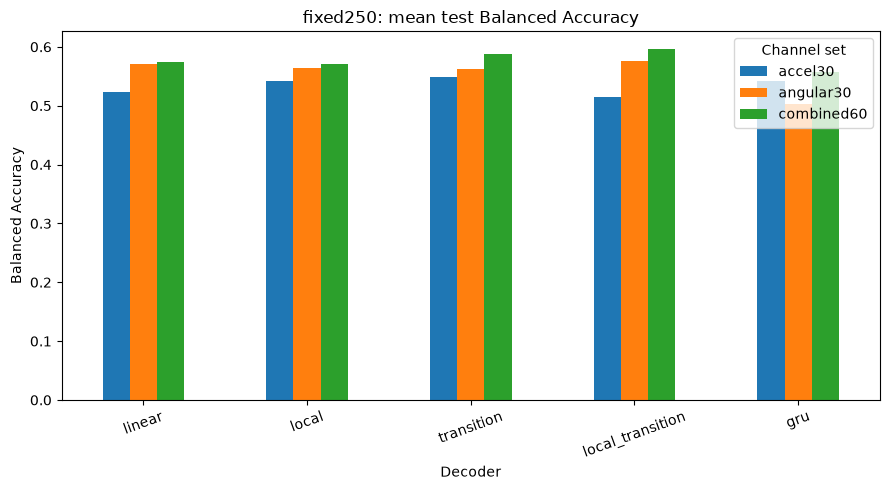

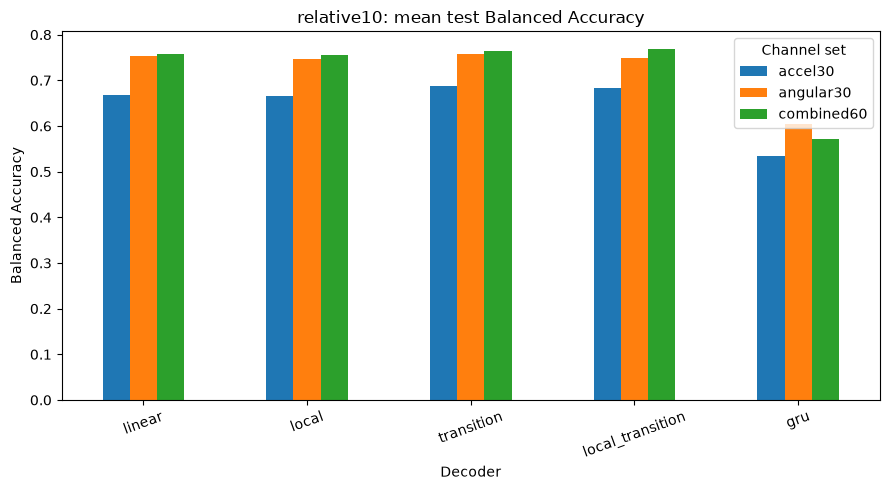

In [3]:
decoder_order = ['linear', 'local', 'transition', 'local_transition', 'gru']
for representation in ['fixed250', 'relative10']:
    view = summary[summary.representation == representation].copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    pivot = view.pivot(index='decoder', columns='channel_set', values='mean_test_ba').reindex(decoder_order)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'{representation}: mean test Balanced Accuracy')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_xlabel('Decoder')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Channel set')
    fig.tight_layout()
    plt.show()

## Structured nonlinear gain over frozen Linear

Positive values indicate information recovered beyond the position-aware Linear baseline.

In [4]:
gain_columns = [
    'local_minus_linear',
    'transition_minus_linear',
    'local_transition_minus_linear',
    'gru_minus_linear',
]
gain_summary = (
    paired.groupby(['representation', 'channel_set'])[gain_columns]
    .agg(['mean', 'std'])
)
display(gain_summary.round(4))

local_minus_linear         transition_minus_linear  \
                                         mean     std                    mean   
representation channel_set                                                      
fixed250       accel30                 0.0187  0.0184                  0.0246   
               angular30              -0.0066  0.0187                 -0.0097   
               combined60             -0.0025  0.0266                  0.0145   
relative10     accel30                -0.0015  0.0214                  0.0199   
               angular30              -0.0059  0.0139                  0.0042   
               combined60             -0.0025  0.0113                  0.0065   

                                   local_transition_minus_linear          \
                               std                          mean     std   
representation channel_set                                                 
fixed250       accel30      0.0201                       -0.0099  0.0304   
               angular30    0.0480                        0.0047  0.0280   
               combined60   0.0527                        0.0225  0.0508   
relative10     accel30      0.0304                        0.0157  0.0285   
               angular30    0.0177                       -0.0044  0.0047   
               combined60   0.0243                        0.0116  0.0120   

                           gru_minus_linear          
                                       mean     std  
representation channel_set                           
fixed250       accel30               0.0177  0.0733  
               angular30            -0.0677  0.0531  
               combined60           -0.0162  0.0580  
relative10     accel30              -0.1335  0.0858  
               angular30            -0.1475  0.0413  
               combined60           -0.1848  0.0986

,representation,channel_set,n_splits,mean_gain_pp,sd_gain_pp
0,fixed250,accel30,5,1.87,1.84
1,fixed250,angular30,5,-0.66,1.87
2,fixed250,combined60,5,-0.25,2.66
3,relative10,accel30,5,-0.15,2.14
4,relative10,angular30,5,-0.59,1.39
5,relative10,combined60,5,-0.25,1.13


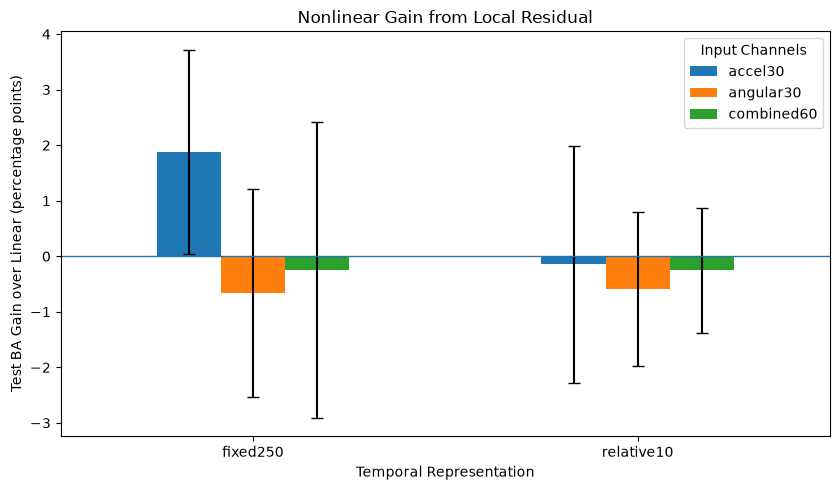

In [7]:
# Nonlinear gain only:
# (Linear + Local residual) - Linear

gain_col = "local_minus_linear"

local_gain = paired[
    ["representation", "channel_set", "split_seed", gain_col]
].copy()

# Convert BA difference to percentage points
local_gain["nonlinear_gain_pp"] = 100.0 * local_gain[gain_col]

# ------------------------------------------------------------
# Summary across the 5 paired user-disjoint splits
# ------------------------------------------------------------
local_gain_summary = (
    local_gain
    .groupby(["representation", "channel_set"], as_index=False)
    .agg(
        n_splits=("split_seed", "nunique"),
        mean_gain_pp=("nonlinear_gain_pp", "mean"),
        sd_gain_pp=("nonlinear_gain_pp", "std"),
    )
)

display(local_gain_summary.round(2))

# ------------------------------------------------------------
# Plot: nonlinear gain only
# ------------------------------------------------------------
representation_order = ["fixed250", "relative10"]
channel_order = ["accel30", "angular30", "combined60"]

mean_pivot = (
    local_gain_summary
    .pivot(
        index="representation",
        columns="channel_set",
        values="mean_gain_pp",
    )
    .reindex(index=representation_order, columns=channel_order)
)

sd_pivot = (
    local_gain_summary
    .pivot(
        index="representation",
        columns="channel_set",
        values="sd_gain_pp",
    )
    .reindex(index=representation_order, columns=channel_order)
)

fig, ax = plt.subplots(figsize=(8.5, 5.0))

mean_pivot.plot(
    kind="bar",
    yerr=sd_pivot,
    capsize=4,
    ax=ax,
)

ax.axhline(0, linewidth=1)
ax.set_title("Nonlinear Gain from Local Residual")
ax.set_ylabel("Test BA Gain over Linear (percentage points)")
ax.set_xlabel("Temporal Representation")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Input Channels")

fig.tight_layout()
plt.show()

## Nonlinear sensor-fusion synergy

`combined_gain_minus_angular_gain > 0` means the residual improvement above Linear is larger for `combined60` than for `angular30`. This is evidence for additional nonlinear complementarity, not by itself proof of a specific cross-modal interaction mechanism.

In [5]:
display(
    synergy.groupby(['representation', 'decoder'])[[
        'combined_gain_minus_angular_gain',
        'combined_gain_minus_accel_gain',
    ]].agg(['mean', 'std']).round(4)
)

combined_gain_minus_angular_gain          \
                                                            mean     std   
representation decoder                                                     
fixed250       local                                      0.0041  0.0280   
               local_transition                           0.0178  0.0718   
               transition                                 0.0242  0.0770   
relative10     local                                      0.0034  0.0174   
               local_transition                           0.0160  0.0132   
               transition                                 0.0023  0.0302   

                                combined_gain_minus_accel_gain          
                                                          mean     std  
representation decoder                                                  
fixed250       local                                   -0.0212  0.0294  
               local_transition                         0.0324  0.0453  
               transition                              -0.0101  0.0510  
relative10     local                                   -0.0010  0.0178  
               local_transition                        -0.0040  0.0301  
               transition                              -0.0135  0.0421

## Structured residual versus GRU

In [6]:
display(
    paired.groupby(['representation', 'channel_set'])['local_transition_minus_gru']
    .agg(['mean', 'std', lambda s: int((s > 0).sum())])
    .rename(columns={'<lambda_0>': 'local_transition_better_splits'})
    .round(4)
)

mean     std  local_transition_better_splits
representation channel_set                                                
fixed250       accel30     -0.0277  0.0599                               2
               angular30    0.0724  0.0359                               5
               combined60   0.0387  0.0679                               3
relative10     accel30      0.1492  0.0831                               5
               angular30    0.1431  0.0392                               5
               combined60   0.1964  0.1042                               5